Data Loading

In [1]:
# loading the data -> data visualization -> train test split
# -> model building -> training -> evaluation -> streamlit application

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt


In [3]:
df  = pd.read_csv('../data/spam.tsv', sep='\t')
df.head()

,label,message,length,punct
0,ham,"Go until jurong point, crazy.. Available only ...",111,9
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,6
3,ham,U dun say so early hor... U c already then say...,49,6
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,2


In [4]:
df.isnull().sum()

label      0
message    0
length     0
punct      0
dtype: int64

In [5]:
df.shape

(5585, 4)

In [6]:
df['label'].value_counts()

label
ham     4828
spam     757
Name: count, dtype: int64

Dataset Balancing

In [7]:
ham = df[df['label']=='ham']
ham.shape

(4828, 4)

In [8]:
spam = df[df['label']=='spam']
spam.shape

(757, 4)

In [9]:
ham = ham.sample(spam.shape[0])

In [10]:
ham.shape

(757, 4)

In [11]:
data = pd.concat([ham, spam], axis=0, ignore_index=True)

In [12]:
data.shape

(1514, 4)

In [13]:
data.sample(5)

,label,message,length,punct
624,ham,TaKe CaRE n gET WeLL sOOn,25,0
52,ham,What happened to our yo date?,29,1
977,spam,Bought one ringtone and now getting texts cost...,81,0
429,ham,"U so lousy, run already come back then half de...",58,7
740,ham,HELLO U.CALL WEN U FINISH WRK.I FANCY MEETIN U...,132,5


Exploratory Data Analysis

In [14]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = (10, 4)
plt.style.use('ggplot')

In [15]:
ham.columns

Index(['label', 'message', 'length', 'punct'], dtype='object')

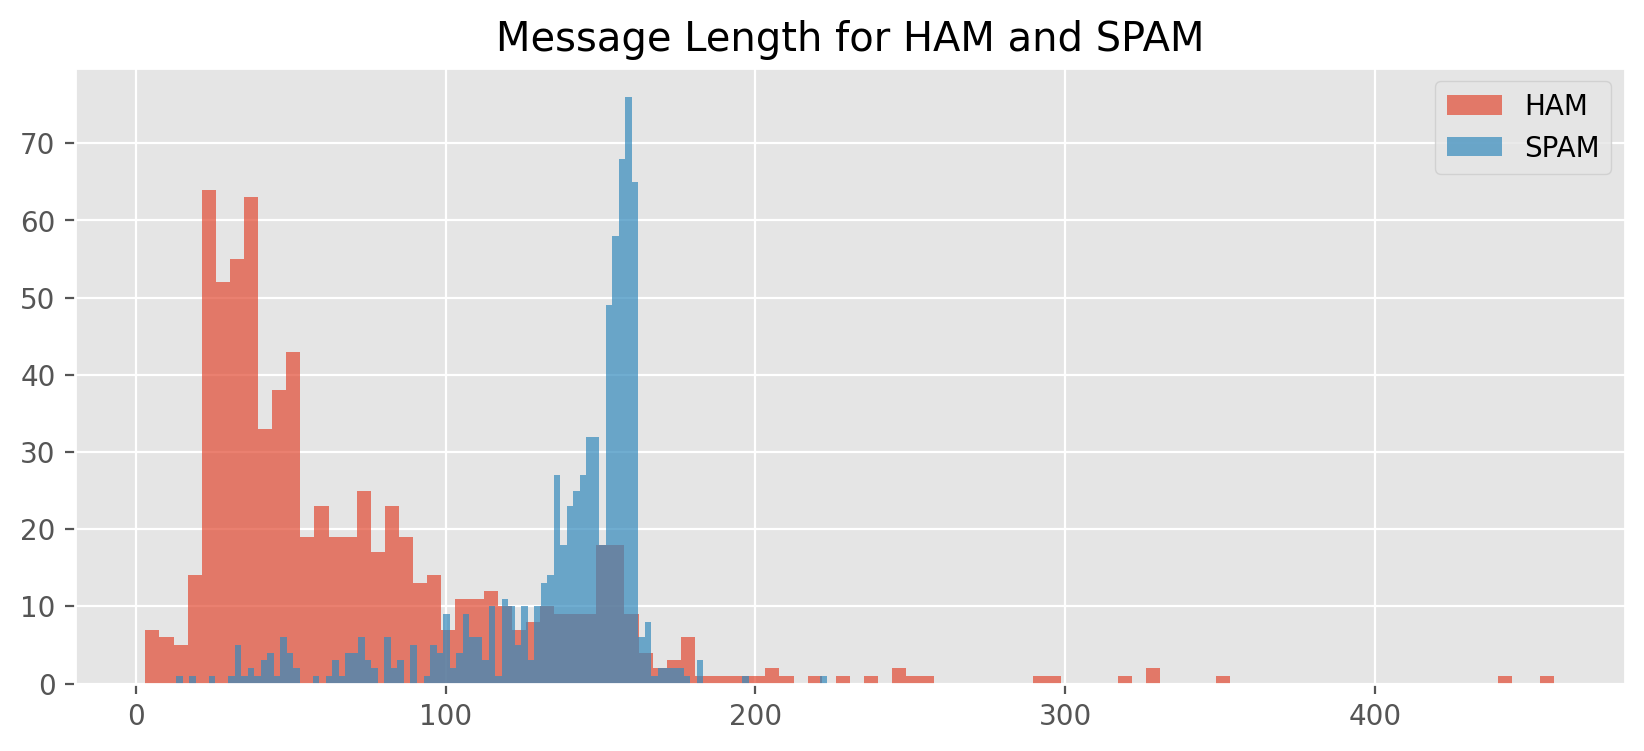

In [16]:
plt.hist(ham['length'], bins=100, alpha=0.7, label='HAM')
plt.hist(spam['length'], bins=100, alpha=0.7, label='SPAM')
plt.title('Message Length for HAM and SPAM')
plt.legend()
plt.show()

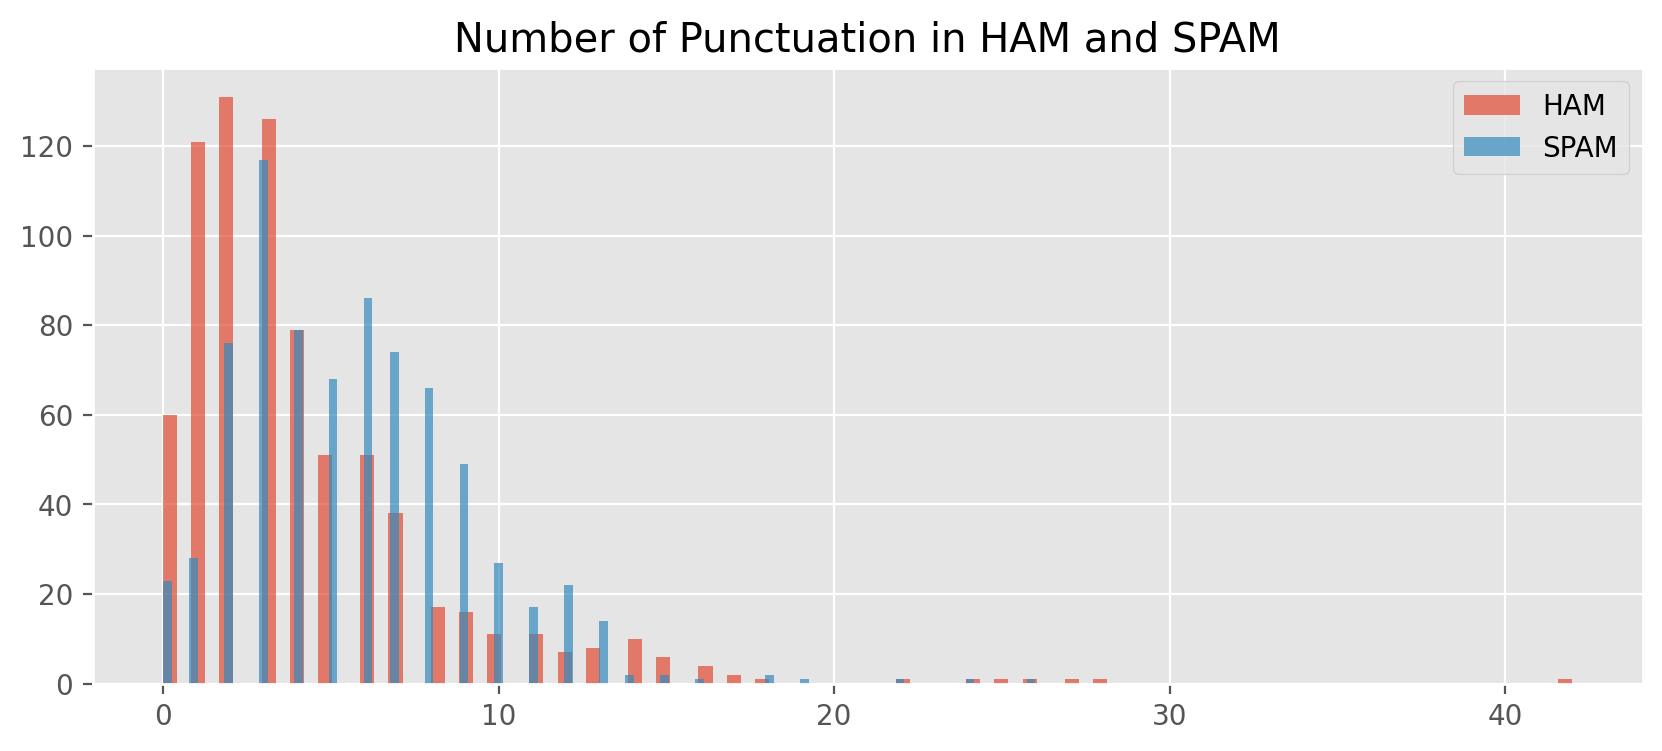

In [17]:
plt.hist(ham['punct'], bins=100, alpha=0.7, label='HAM')
plt.hist(spam['punct'], bins=100, alpha=0.7, label='SPAM')
plt.title('Number of Punctuation in HAM and SPAM')
plt.legend()
plt.show()

Data Preparation for Training

In [18]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

In [19]:
X_train, X_test, y_train, y_test = train_test_split(data['message'], data['label'],
                                                   test_size=0.2, random_state=0,
                                                   shuffle=True, stratify=data['label'])

X_train.shape, X_test.shape

((1211,), (303,))

In [20]:
# model Building
clf = Pipeline([('tfidf', TfidfVectorizer()),
                ('rfc', RandomForestClassifier(n_estimators=100, n_jobs=-1))])

clf.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('rfc', RandomForestClassifier(n_jobs=-1))])

In [21]:
y_pred = clf.predict(X_test)

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.92      0.97      0.95       152
        spam       0.97      0.91      0.94       151

    accuracy                           0.94       303
   macro avg       0.95      0.94      0.94       303
weighted avg       0.95      0.94      0.94       303



In [23]:
clf.predict(['you have won lottery ticket worth $1000, please click here to claim',
            'hi, how are you doing today?'])

array(['spam', 'ham'], dtype=object)

In [24]:
clf.classes_

array(['ham', 'spam'], dtype=object)

Save and Load Model

In [25]:
import joblib

joblib.dump(clf, '../models/model.joblib')

['../models/model.joblib']

In [26]:
model = joblib.load(open('../models/model.joblib', 'rb'))

In [27]:
model.predict(['you have won lottery ticket worth $1000, please click here to claim',
            'hi, how are you doing today?'])

array(['spam', 'ham'], dtype=object)